In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     print(f'{dirname} - {len(filenames)}')

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
TRAIN_PATH='/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/'
VAL_PATH='/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/'
TEST_PATH='/kaggle/input/datasets/puneet6060/intel-image-classification/seg_pred/seg_pred/'

In [3]:
len(os.listdir(TRAIN_PATH)),len(os.listdir(VAL_PATH)),len(os.listdir(TEST_PATH))

(6, 6, 7301)

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

In [5]:
targets = os.listdir(TRAIN_PATH)
targets

['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']

In [6]:
IMG_DIM=224

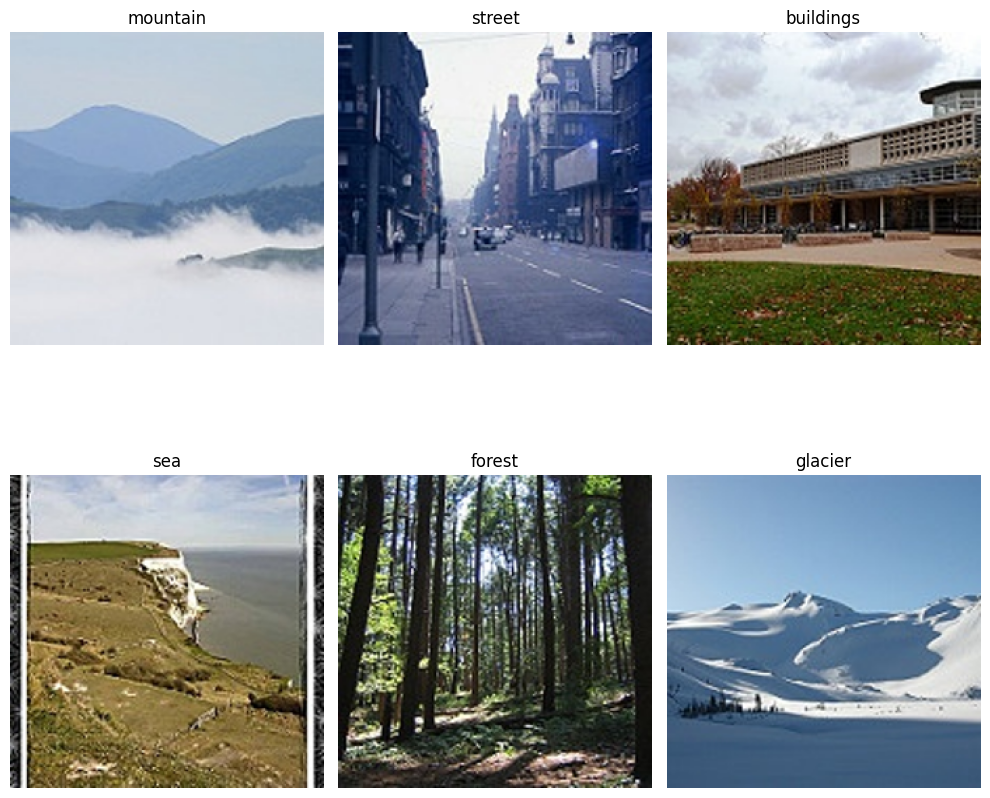

In [7]:
fig, ax = plt.subplots(2, 3, figsize=(10,10))

for axis, target in zip(ax.ravel(), targets):
    class_dir = os.path.join(TRAIN_PATH, target)

    img_name = os.listdir(class_dir)[0]
    img_path = os.path.join(class_dir, img_name)

    img = Image.open(img_path)
    img = img.resize((IMG_DIM, IMG_DIM))

    axis.imshow(img)
    axis.set_title(target)
    axis.axis("off")

plt.tight_layout()
plt.show()

In [8]:
class_to_idx = {
    cls_name: idx
    for idx, cls_name in enumerate(sorted(targets))
}
idx_to_class = {
    idx: cls
    for idx, cls in enumerate(sorted(targets))    
}
idx_to_class, class_to_idx

({0: 'buildings',
  1: 'forest',
  2: 'glacier',
  3: 'mountain',
  4: 'sea',
  5: 'street'},
 {'buildings': 0,
  'forest': 1,
  'glacier': 2,
  'mountain': 3,
  'sea': 4,
  'street': 5})

In [9]:
class TrainValDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {
            cls_name: idx
            for idx, cls_name in enumerate(self.classes)
        }

        self.samples = []  # list of (img_path, classIdx)

        for cls_name in self.classes:
            cls_dir = os.path.join(root_dir, cls_name)

            for img_name in os.listdir(cls_dir):
                img_path = os.path.join(cls_dir, img_name)

                self.samples.append(
                    (img_path, self.class_to_idx[cls_name])
                )


    def __len__(self):
        return len(self.samples)
        

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label

In [10]:
class TestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.samples = []  # list of img_path
        for img_path in os.listdir(self.root_dir):
            self.samples.append(os.path.join(root_dir, img_path))

    def __len__(self):
        return len(self.samples)
        

    def __getitem__(self, idx):
        img_path = self.samples[idx]

        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img

In [11]:
train_tranform = transforms.Compose([
    # transforms.Resize((IMG_DIM, IMG_DIM)),
    transforms.RandomResizedCrop(IMG_DIM),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_val_transform = transforms.Compose([
    transforms.Resize((IMG_DIM, IMG_DIM)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [12]:
train_ds = TrainValDataset(TRAIN_PATH, train_tranform)
val_ds = TrainValDataset(TRAIN_PATH, test_val_transform)
test_ds = TestDataset(TEST_PATH, test_val_transform)

In [13]:
batch_size=64

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size)
test_loader = DataLoader(test_ds, batch_size=batch_size)

In [14]:
images, labels = next(iter(train_loader))
images.shape, labels

(torch.Size([64, 3, 224, 224]),
 tensor([4, 5, 1, 4, 3, 1, 2, 0, 5, 0, 3, 0, 3, 3, 3, 1, 5, 0, 2, 2, 5, 0, 3, 4,
         5, 2, 4, 3, 3, 5, 2, 5, 0, 5, 1, 4, 3, 4, 4, 0, 0, 5, 4, 2, 4, 2, 5, 1,
         3, 2, 5, 2, 4, 4, 2, 4, 5, 3, 2, 4, 1, 4, 3, 5]))

In [15]:
from torchvision.models import (
    alexnet, AlexNet_Weights,
    efficientnet_b3, EfficientNet_B3_Weights,
    mobilenet_v3_large, MobileNet_V3_Large_Weights
)

models = {
    "AlexNet": alexnet(weights=AlexNet_Weights.DEFAULT),

    "EfficientNet_B3": efficientnet_b3(
        weights=EfficientNet_B3_Weights.DEFAULT
    ),

    "MobileNetV3_Large": mobilenet_v3_large(
        weights=MobileNet_V3_Large_Weights.DEFAULT
    )
}

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 203MB/s] 


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 171MB/s] 


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 122MB/s] 


In [16]:
weights_dict = {
    "AlexNet": AlexNet_Weights.DEFAULT,
    "EfficientNet_B3": EfficientNet_B3_Weights.DEFAULT,
    "MobileNetV3_Large": MobileNet_V3_Large_Weights.DEFAULT
}

for name, weights in weights_dict.items():
    print(f"\n{name}")

    categories = weights.meta["categories"]

    for t in targets:
        if t in categories:
            print(f"{t} is in class index {categories.index(t)}")


AlexNet

EfficientNet_B3

MobileNetV3_Large


In [17]:
len(weights_dict['AlexNet'].meta['categories']), len(weights_dict['EfficientNet_B3'].meta['categories']), len(weights_dict['MobileNetV3_Large'].meta['categories'])

(1000, 1000, 1000)

In [18]:
for name, model in models.items():

    # freeze all layers
    for param in model.parameters():
        param.requires_grad = False


    if name == "AlexNet":
        model.classifier[6] = nn.Linear(model.classifier[6].in_features,6)

        for param in model.classifier[6].parameters():
            param.requires_grad = True


    elif name == "EfficientNet_B3":
        model.classifier[1] = nn.Linear(model.classifier[1].in_features,6)

        for param in model.classifier[1].parameters():
            param.requires_grad = True


    elif name == "MobileNetV3_Large":
        model.classifier[3] = nn.Linear(model.classifier[3].in_features,6)

        for param in model.classifier[3].parameters():
            param.requires_grad = True

In [19]:
models['EfficientNet_B3'].classifier

Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1536, out_features=6, bias=True)
)

In [20]:
for name, model in models.items():
    for name, param in model.named_parameters():
        if param.requires_grad:
            print(name)

classifier.6.weight
classifier.6.bias
classifier.1.weight
classifier.1.bias
classifier.3.weight
classifier.3.bias


In [21]:
for name, model in models.items():
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    
    print(f"Trainable {name}: {trainable:,}")
    print(f"Total: {total:,}\n")

Trainable AlexNet: 24,582
Total: 57,028,422

Trainable EfficientNet_B3: 9,222
Total: 10,705,454

Trainable MobileNetV3_Large: 7,686
Total: 4,209,718



In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [23]:
for name in models:
    models[name] = models[name].to(device)

In [24]:
criterion = nn.CrossEntropyLoss()

In [25]:
epochs = 30
patience = 5

In [26]:
for name, model in models.items():
    print(f"\nTraining {name}")

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=0.0001,
        weight_decay=1e-4
    )

    best_val_loss = float("inf")
    counter = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for imgs, labels in train_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(imgs)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        # validation
        model.eval()

        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)
                val_loss += loss.item()

                preds = outputs.argmax(dim=1)

                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(val_loader)
        accuracy = 100 * correct / total

        print(
            f"{name} Epoch [{epoch+1}/{epochs}] "
            f"Train_Loss: {train_loss:.4f} "
            f"Val_Loss: {val_loss:.4f} "
            f"Val_Acc: {accuracy:.2f}%"
        )


        # save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0

            torch.save(
                model.state_dict(),f"{name}_best_model.pth")
        else:
            counter += 1

        if counter >= patience:
            print(f"{name}: Early Stopping")
            break


Training AlexNet
AlexNet Epoch [1/30] Train_Loss: 0.8249 Val_Loss: 0.3465 Val_Acc: 88.28%
AlexNet Epoch [2/30] Train_Loss: 0.5553 Val_Loss: 0.2899 Val_Acc: 89.96%
AlexNet Epoch [3/30] Train_Loss: 0.5056 Val_Loss: 0.2694 Val_Acc: 90.30%
AlexNet Epoch [4/30] Train_Loss: 0.4892 Val_Loss: 0.2548 Val_Acc: 90.93%
AlexNet Epoch [5/30] Train_Loss: 0.4770 Val_Loss: 0.2474 Val_Acc: 91.21%
AlexNet Epoch [6/30] Train_Loss: 0.4757 Val_Loss: 0.2374 Val_Acc: 91.68%
AlexNet Epoch [7/30] Train_Loss: 0.4586 Val_Loss: 0.2326 Val_Acc: 91.68%
AlexNet Epoch [8/30] Train_Loss: 0.4554 Val_Loss: 0.2303 Val_Acc: 91.78%
AlexNet Epoch [9/30] Train_Loss: 0.4597 Val_Loss: 0.2227 Val_Acc: 91.88%
AlexNet Epoch [10/30] Train_Loss: 0.4461 Val_Loss: 0.2200 Val_Acc: 92.02%
AlexNet Epoch [11/30] Train_Loss: 0.4480 Val_Loss: 0.2139 Val_Acc: 92.20%
AlexNet Epoch [12/30] Train_Loss: 0.4315 Val_Loss: 0.2153 Val_Acc: 92.07%
AlexNet Epoch [13/30] Train_Loss: 0.4369 Val_Loss: 0.2135 Val_Acc: 92.10%
AlexNet Epoch [14/30] Train_L

In [27]:
model = models["AlexNet"]

# load its saved weights
model.load_state_dict(
    torch.load(
        "/kaggle/working/AlexNet_best_model.pth",
        map_location=device
    )
)

model = model.to(device)

In [28]:
model.eval()
correct, total = 0,0

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs)
        preds = outputs.argmax(dim=1)
        
        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct/total
print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 0.93%


In [29]:
next(iter(test_loader))[0].shape, len(next(iter(test_loader)))

(torch.Size([3, 224, 224]), 64)

In [30]:
model.eval()

imgs = next(iter(test_loader))
with torch.no_grad():
    outputs = model(imgs.to(device))
    preds = outputs.argmax(dim=1).cpu()

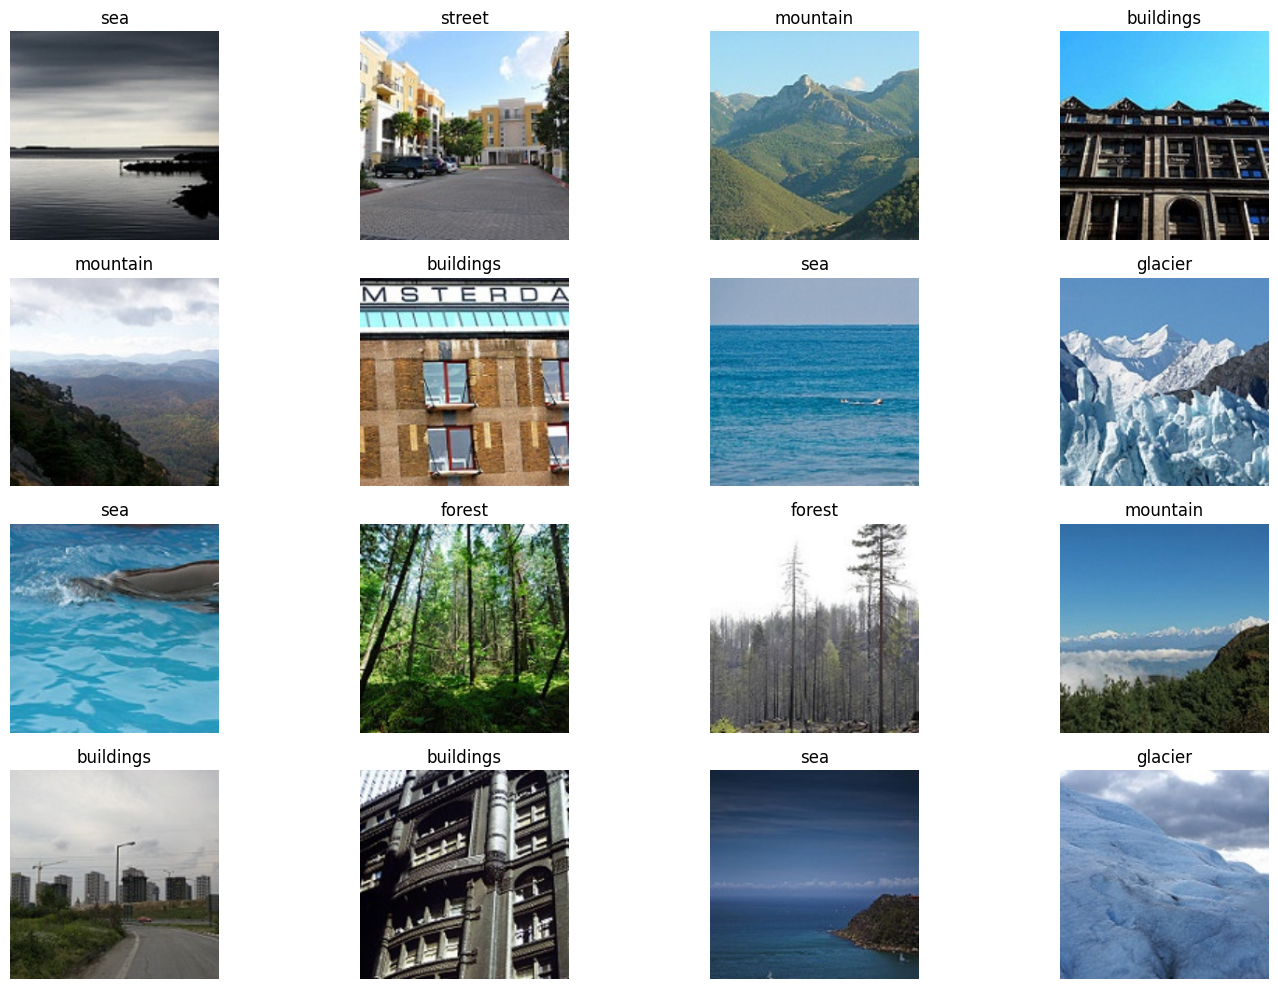

In [31]:
fig, axes = plt.subplots(4, 4, figsize=(15, 10))

for i, ax in enumerate(axes.ravel()):
    img = imgs[i]

    # Undo normalization
    img = img.permute(1, 2, 0)
    img = img * torch.tensor([0.229, 0.224, 0.225]) + \
          torch.tensor([0.485, 0.456, 0.406])

    img = img.clamp(0, 1)

    ax.imshow(img)
    ax.set_title((sorted(targets))[preds[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()